<a href="https://colab.research.google.com/github/enriquefroes/reforcos-galo-cruzeiro-2026/blob/main/notebooks/01_ranking_reforcos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_reforcos_galo_cruzeiro'
except ImportError:
    BASE = './analise_reforcos_galo_cruzeiro'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)
for arq in ['transferencias.csv', 'estatisticas.csv', 'pares.csv']:
    if not os.path.exists(os.path.join(DADOS, arq)):
        raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb')
transf = pd.read_csv(os.path.join(DADOS, 'transferencias.csv'))
est = pd.read_csv(os.path.join(DADOS, 'estatisticas.csv'))
pares = pd.read_csv(os.path.join(DADOS, 'pares.csv'))


PESOS = {'nota': 0.5, 'metricas': 0.3, 'titularidade': 0.2}
MIN_MINUTOS = 450
GRUPO = {'ATA': 'Ataque', 'PD/PE': 'Ataque', 'MC': 'Meio-campo', 'MEI': 'Meio-campo',
         'LD': 'Laterais', 'LE': 'Laterais', 'ZAG': 'Zagueiros', 'GOL': 'Goleiros'}
METRICAS = {
    'Ataque':     ['GA_90', 'xGxA_90', 'passes_decisivos_90', 'dribles_certos_90'],
    'Meio-campo': ['GA_90', 'passes_decisivos_90', 'passes_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Laterais':   ['GA_90', 'passes_decisivos_90', 'cruzamentos_certos_90', 'desarmes_90', 'interceptacoes_90'],
    'Zagueiros':  ['desarmes_90', 'interceptacoes_90', 'chutes_bloqueados_90', 'duelos_aereos_vencidos_90', 'passes_certos_90'],
    'Goleiros':   ['gols_evitados_90', 'jogos_sem_sofrer_gol_pct'],
}
CORES_CLUBE = {'Atlético-MG': '#111111', 'Cruzeiro': '#1d4ed8'}
SIGLA = {'Atlético-MG': 'CAM', 'Cruzeiro': 'CRU'}

def percentil(s):
    """Posição relativa de 0 (pior) a 1 (melhor) dentro do grupo de referência."""
    s = s.dropna()
    if len(s) < 2:
        return pd.Series(0.5, index=s.index)
    return (s.rank(method='average') - 1) / (len(s) - 1)

def preparar(est, transf):
    d = est.merge(transf[['clube', 'movimento', 'jogador', 'janela', 'operacao', 'valor_milhoes_euros']],
                  on=['clube', 'movimento', 'jogador'], how='left')
    n = d['minutos'] / 90
    d['grupo'] = d['posicao'].map(GRUPO)
    d['GA'] = d['gols'].fillna(0) + d['assistencias'].fillna(0)
    d['GA_90'] = d['GA'] / n
    d['xGxA_90'] = (d['xg'] + d['xa'].fillna(0)) / n
    for c in ['passes_decisivos', 'dribles_certos', 'passes_certos', 'cruzamentos_certos', 'desarmes',
              'interceptacoes', 'chutes_bloqueados', 'duelos_aereos_vencidos', 'gols_evitados']:
        d[c + '_90'] = d[c] / n
    d['jogos_sem_sofrer_gol_pct'] = d['jogos_sem_sofrer_gol'] / d['jogos']
    d['nota_media'] = (d['nota_sofascore'] + d['nota_fotmob']) / 2
    d['min_por_jogo'] = d['minutos'] / d['jogos']
    d['titularidade'] = (d['min_por_jogo'] / 90).clip(upper=1)

    ref = d['minutos'] >= MIN_MINUTOS
    d['p_nota'] = np.nan
    d['p_metricas'] = np.nan
    for g, cols in METRICAS.items():
        idx = d.index[ref & (d['grupo'] == g)]
        d.loc[idx, 'p_nota'] = percentil(d.loc[idx, 'nota_media'])
        pcts = pd.concat([percentil(d.loc[idx, c]) for c in cols], axis=1)
        d.loc[idx, 'p_metricas'] = pcts.mean(axis=1)
    d['score'] = 100 * (PESOS['nota'] * d['p_nota'] + PESOS['metricas'] * d['p_metricas']
                        + PESOS['titularidade'] * d['titularidade'])
    d.loc[~ref, 'score'] = np.nan
    d['n_ref_grupo'] = d['grupo'].map(d[ref].groupby('grupo').size())
    return d

df = preparar(est, transf)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [2]:
r = df[(df['movimento'] == 'chegada') & (df['entra_no_ranking'] == 'sim') & (df['grupo'] != 'Goleiros')].copy()
r = r.sort_values('score', ascending=False)
r['posicao_ranking'] = range(1, len(r) + 1)
cols = ['posicao_ranking', 'jogador', 'clube', 'grupo', 'operacao', 'valor_milhoes_euros', 'minutos',
        'nota_media', 'GA_90', 'titularidade', 'p_nota', 'p_metricas', 'score']
tabela = r[cols].round(2)
tabela.to_csv(os.path.join(TAB, '01_ranking_reforcos.csv'), index=False)
tabela

,posicao_ranking,jogador,clube,grupo,operacao,valor_milhoes_euros,minutos,nota_media,GA_90,titularidade,p_nota,p_metricas,score
3,1,Fred,Atlético-MG,Meio-campo,compra,2.00,627,7.17,0.57,0.87,0.88,0.94,89.29
9,2,Vitor Hugo,Atlético-MG,Zagueiros,compra,1.00,2495,6.96,0.11,0.84,1.00,0.60,84.80
8,3,Renan Lodi,Atlético-MG,Laterais,livre,0.00,3823,7.08,0.21,0.94,1.00,0.45,82.38
0,4,Alan Minda,Atlético-MG,Ataque,compra,7.00,1267,6.73,0.43,0.43,0.73,0.82,69.44
15,5,Gerson,Cruzeiro,Meio-campo,compra,27.00,3280,7.12,0.16,0.83,0.75,0.38,65.32
16,6,Wesley,Cruzeiro,Ataque,empréstimo,NaN,476,6.74,0.19,0.53,0.82,0.09,54.21
7,7,Angelo Preciado,Atlético-MG,Laterais,compra,5.00,1366,6.74,0.07,0.66,0.50,0.50,53.20
4,8,Victor Hugo,Atlético-MG,Meio-campo,compra,2.15,2688,6.96,0.27,0.79,0.38,0.50,49.47
1,9,Mateo Cassierra,Atlético-MG,Ataque,compra,7.00,2109,6.67,0.38,0.59,0.45,0.46,48.15
14,10,Bruno Rodrigues,Cruzeiro,Ataque,livre,0.00,794,6.64,0.57,0.33,0.36,0.56,41.49


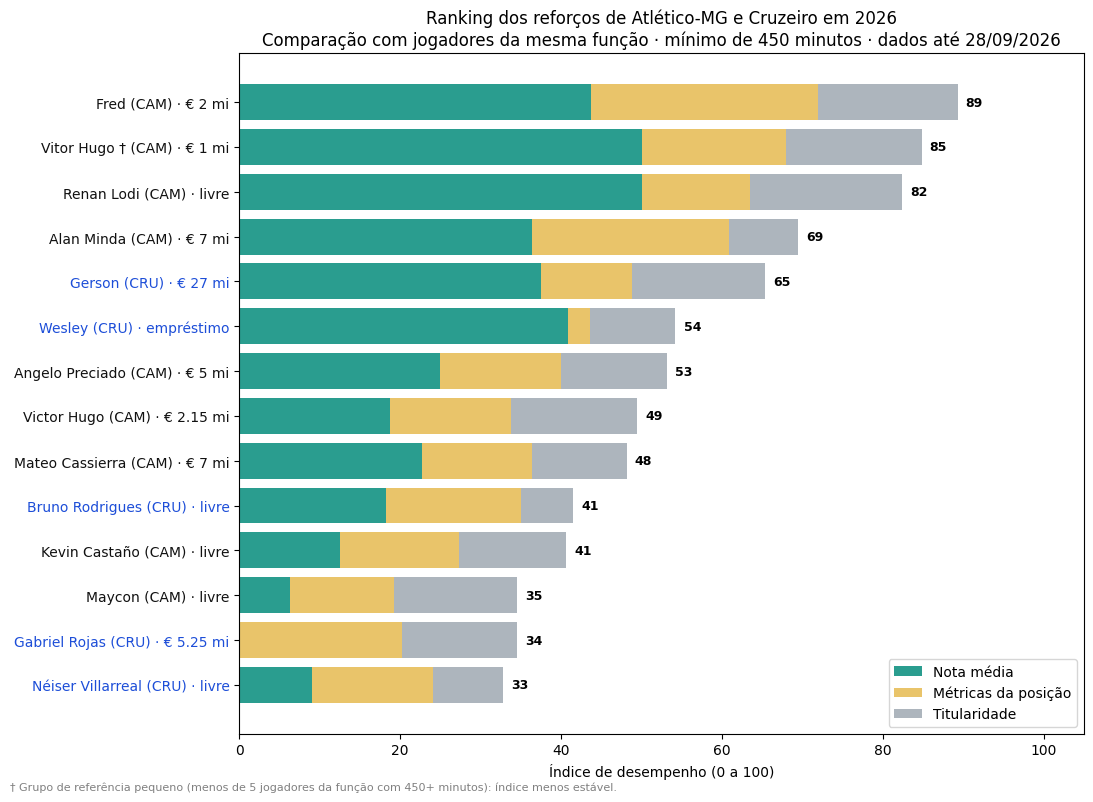

Salvo em /content/drive/MyDrive/analise_reforcos_galo_cruzeiro/graficos/01a_ranking_reforcos.png


In [3]:
t = r.sort_values('score')
partes = {'Nota média': 100 * PESOS['nota'] * t['p_nota'],
          'Métricas da posição': 100 * PESOS['metricas'] * t['p_metricas'],
          'Titularidade': 100 * PESOS['titularidade'] * t['titularidade']}
cores = ['#2a9d8f', '#e9c46a', '#adb5bd']
fig, ax = plt.subplots(figsize=(11, 8))
esq = np.zeros(len(t))
for (nome, v), cor in zip(partes.items(), cores):
    ax.barh(range(len(t)), v, left=esq, color=cor, label=nome)
    esq += v.values
def custo(val, op):
    if pd.notna(val) and val > 0:
        return f'€ {val:g} mi'
    return 'empréstimo' if 'empréstimo' in str(op) else 'livre'
rot = [f"{j}{' †' if n < 5 else ''} ({SIGLA[c]}) · {custo(val, op)}"
       for j, c, val, op, n in zip(t['jogador'], t['clube'], t['valor_milhoes_euros'], t['operacao'], t['n_ref_grupo'])]
ax.set_yticks(range(len(t)))
ax.set_yticklabels(rot)
for i, (lab, cl) in enumerate(zip(ax.get_yticklabels(), t['clube'])):
    lab.set_color(CORES_CLUBE[cl])
for i, s in enumerate(t['score']):
    ax.text(s + 1, i, f'{s:.0f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlim(0, 105)
ax.set_xlabel('Índice de desempenho (0 a 100)')
ax.set_title('Ranking dos reforços de Atlético-MG e Cruzeiro em 2026\n'
             'Comparação com jogadores da mesma função · mínimo de 450 minutos · dados até 28/09/2026', fontsize=12)
ax.legend(loc='lower right')
if (t['n_ref_grupo'] < 5).any():
    fig.text(0.01, 0.005, '† Grupo de referência pequeno (menos de 5 jogadores da função com 450+ minutos): índice menos estável.',
             fontsize=8, color='gray')
salvar('01a_ranking_reforcos.png')

In [4]:
for g, sub in r.groupby('grupo'):
    print(f'\n{g}')
    print(sub.sort_values('score', ascending=False)[['jogador', 'clube', 'nota_media', 'GA_90', 'minutos', 'score']]
          .round(2).to_string(index=False))


Ataque
          jogador       clube  nota_media  GA_90  minutos  score
       Alan Minda Atlético-MG        6.73   0.43     1267  69.44
           Wesley    Cruzeiro        6.74   0.19      476  54.21
  Mateo Cassierra Atlético-MG        6.67   0.38     2109  48.15
  Bruno Rodrigues    Cruzeiro        6.64   0.57      794  41.49
Néiser Villarreal    Cruzeiro        6.54   0.46      981  32.81

Laterais
        jogador       clube  nota_media  GA_90  minutos  score
     Renan Lodi Atlético-MG        7.08   0.21     3823  82.38
Angelo Preciado Atlético-MG        6.74   0.07     1366  53.20
  Gabriel Rojas    Cruzeiro        6.58   0.00      832  34.47

Meio-campo
      jogador       clube  nota_media  GA_90  minutos  score
         Fred Atlético-MG        7.17   0.57      627  89.29
       Gerson    Cruzeiro        7.12   0.16     3280  65.32
  Victor Hugo Atlético-MG        6.96   0.27     2688  49.47
Kevin Castaño Atlético-MG        6.95   0.17      541  40.61
       Maycon Atlético-